# NCA → LFP 迁移学习：Zero-shot / Head-only / Full fine-tune / Scratch

本 notebook **只做迁移**，预训练在 `nca_soh_mlp_v2.ipynb` 里完成。
运行前请先跑完那个 notebook 的第 7 节，确认 `./nca_artifacts/` 下已经有：

```
nca_mlp_ensemble.pt    K 个集成成员的权重
nca_mlp_pre.joblib     x_scaler / y_scaler / 特征定义 / 网络结构超参
```

---

## 要回答的问题

> NCA 上学到的知识，究竟能否帮助 LFP？如果可以，帮助来自哪里？

模型统一拆成特征提取器与回归头 \(f_\theta(x)=g_\psi(h_\phi(x))\)，其中 \(\phi\) 是 `feature` 的参数、
\(\psi\) 是 `head` 的参数。四种方法**只在「初始化方式」和「哪些参数被更新」上不同**，
数据、划分、特征工程全部保持一致。

| 方法 | 初始参数 | LFP 训练时更新什么 | 回答的问题 |
|---|---|---|---|
| Zero-shot | NCA 模型 | 不更新任何参数 | NCA 模型能否直接泛化到 LFP |
| Head-only | NCA 模型 | 只更新 SOH 回归头 \(\psi\) | NCA 特征是否能迁移到 LFP |
| Full fine-tune | NCA 模型 | 更新全部参数 \((\phi,\psi)\) | NCA 知识经过调整后能否适应 LFP |
| Scratch | 随机初始化 | 更新全部参数 | 迁移学习是否比从零训练更好 |

参数更新规则：

\[
\text{Zero-shot:}\quad \phi=\phi_{NCA},\ \psi=\psi_{NCA}
\]

\[
\text{Head-only:}\quad \phi=\phi_{NCA},\qquad \psi \leftarrow \psi-\eta\nabla_\psi L
\]

\[
\text{Full fine-tune:}\quad \phi \leftarrow \phi-\eta_{small}\nabla_\phi L,\qquad
\psi \leftarrow \psi-\eta_{small}\nabla_\psi L
\]

\[
\text{Scratch:}\quad \phi^{(0)},\psi^{(0)}\sim \text{Random},\ \text{再全部更新}
\]

---

## 三条必须守住的实验纪律

1. **同一批 LFP 电池、同一套 train/val/test 划分**，四种方法完全一致，否则比较无意义；
2. **scaler 只在 LFP 训练集上 fit**，测试集标签只用于最后算指标，不参与选 epoch、调超参；
3. **Zero-shot 必须用 NCA 的输入 scaler**，否则送进第一层的数值坐标与预训练时不一致：
   预训练时是 \(x=(x-\mu_{NCA})/\sigma_{NCA}\)，若换成 LFP 的 \(\mu,\sigma\)，模型看到的就是另一个空间。
   Head-only 严格冻结 feature，同样默认用 NCA 输入 scaler；Full fine-tune 与 Scratch 用 LFP 训练集 scaler。
4. **LFP 训练标签必须稀缺**。迁移学习的卖点是省目标域标注；目标域标签一旦充足，
   Scratch 必然追平甚至反超，四种方法的差距会收敛到噪声里。所以本 notebook 把
   LFP 电池分成「测试池 / 验证池 / 训练池」，主实验只从训练池里抽 `N_TRAIN_CELLS` 块
   （默认 5 块）作为训练集，其余留给第 7 节做标签量扫描。
   这也意味着 **batch size 必须随样本量自适应**，否则小样本时 Scratch 的梯度更新步数
   会被压到个位数，测出来的迁移增益是假的。


In [2]:
import os
import re
import time
import copy
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (6, 4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 环境就绪 | PyTorch: {torch.__version__} | 训练设备: {device}")


🚀 环境就绪 | PyTorch: 2.13.0+cu126 | 训练设备: cuda


## 1. 配置

`LFP_DATA_ROOT` 是**唯一必须改**的地方（指向 LFP 目标域数据根目录，结构与 NCA 一致：
一个电池一个文件夹，文件夹里是各次循环的数据文件，文件内含 `Temperature (°C)` 列）。

学习率的差异是有意的：Full fine-tune 从 NCA 的解出发，用大学习率会迅速冲掉预训练知识，所以
\(\eta_{full}=10^{-4}\) 远小于 Scratch 的 \(\eta_{scratch}=2\times10^{-3}\)。

---

### 关于 `N_TRAIN_CELLS`（标签预算）

LFP 侧有约 200 块电池，但**迁移学习的卖点是省目标域标注**：目标域标签一旦充足，
Scratch 必然追平甚至反超，四种方法的差距会收敛到噪声里。用 140 块电池训练出来的
\(\Delta R^2\) 无论正负，都回答不了「要不要做迁移」这个问题。

所以这里把电池分成三部分：

```text
测试池 20%（~40 块）  一次划定，永不改动，所有方法/所有标签量共用的公共标尺
验证池 10%（~20 块）  固定，只用于早停
训练池 70%（~140 块） 不是训练集，是可抽样的池子
```

主实验只从训练池里抽 `N_TRAIN_CELLS` 块（默认 5 块）作为真正的训练集，
其余电池留给第 7 节的标签效率曲线做规模扫描。

`N_TRAIN_CELLS = None` 则用满整个训练池（等价于原版行为，用于对照）。


In [3]:
# ==================== 路径 ====================
NCA_ARTIFACT_DIR = Path(r"C:\Users\huang\WPSDrive\19950006\WPS云盘\L2p\30-MA\code\nca_artifacts")          # 与 NCA notebook 第 7 节的 SAVE_DIR 一致
NCA_PRE_PATH  = NCA_ARTIFACT_DIR / "nca_mlp_pre.joblib"
NCA_CKPT_PATH = NCA_ARTIFACT_DIR / "nca_mlp_ensemble.pt"

LFP_DATA_ROOT = r"C:\Users\huang\OneDrive\桌面\A123_output_rc_soh_1_300_mixed_conditions"          # ← 改成你的 LFP 目标域数据根目录

RESULT_DIR = Path("./transfer_results")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# ==================== LFP 划分（四种方法共用，绝不改动）====================
LFP_TEST_RATIO = 0.20      # 测试电池占比 → ~40 块，永远不变，所有方法的公共标尺
LFP_VAL_RATIO  = 0.10      # 验证电池占比（相对全体）→ ~20 块，只用于早停
SPLIT_SEED     = 42
SPLIT_BY_CELL  = True      # True=按电池分组划分（推荐）；False=按样本行随机（会泄露电池身份）
# 剩下 ~70%（~140 块）是"训练池"，不是训练集 —— 主实验只从中抽 N_TRAIN_CELLS 块

# ==================== 标签预算（迁移实验的核心自变量）====================
# 迁移学习要证明的是"少量目标域标签也能work"，所以训练电池数必须是自变量而非常数。
# 主实验建议取 3~5 块：对应"新化学体系刚到手、做了几块完整老化测试"的现实场景，
# 也是迁移增益最显著的区间。完整的规模扫描见第 7 节。
N_TRAIN_CELLS = 5          # 主实验实际使用的训练电池数；None = 用满整个训练池
BUDGET_SEED   = 42         # 从训练池抽这 N 块的随机种子

# ==================== 训练超参 ====================
SEEDS        = [42, 2024, 9999]   # 集成成员数；也决定 Scratch 训几个模型
EPOCHS       = 200
PATIENCE     = 20
BATCH_SIZE   = 1024               # batch size 上限；实际值由 adaptive_bs() 按样本量下调
WEIGHT_DECAY = 3e-4

# batch size 自适应：保证每个 epoch 至少有这么多步梯度更新。
# 若小样本时仍固定 bs=1024，一个 epoch 只有 1 步，200 epochs = 200 步梯度更新，
# Scratch 从随机初始化出发根本没收敛就被早停 —— 那时测到的不是"迁移有效"，
# 而是"Scratch 被人为饿死了"。这是小样本对照实验里最容易犯的错。
TARGET_STEPS_PER_EPOCH = 15
MIN_BATCH              = 32

HEAD_LR    = 1e-3    # Head-only：只训 33 个参数，可以用较大 lr
FULL_LR    = 1e-4    # Full fine-tune：小 lr，避免破坏 NCA 知识
SCRATCH_LR = 2e-3    # Scratch：与 NCA 预训练时同量级

# ==================== 每种方法用哪套输入 scaler ====================
# "nca" = 复用 NCA 训练时的 x_scaler；"lfp" = 在 LFP 训练集上重新 fit
SCALER_POLICY = {
    "Zero-shot":      "nca",
    "Head-only":      "nca",
    "Full fine-tune": "lfp",
    "Scratch":        "lfp",
}

# ==================== 温度列（与 NCA notebook 保持一致）====================
TEMPERATURE_COL_ALIASES = [
    "Temperature (°C)", "Temperature(°C)", "Temperature (C)", "Temperature(C)",
    "Temperature (degC)", "Temperature", "Temp (°C)", "Temp (C)", "Temp", "T (°C)",
]

print("配置就绪。LFP_DATA_ROOT =", LFP_DATA_ROOT)
print(f"标签预算 N_TRAIN_CELLS = {N_TRAIN_CELLS if N_TRAIN_CELLS else '用满训练池'}")


配置就绪。LFP_DATA_ROOT = C:\Users\huang\OneDrive\桌面\A123_output_rc_soh_1_300_mixed_conditions
标签预算 N_TRAIN_CELLS = 5


## 2. 加载 NCA 预训练产物

网络结构必须与预训练时**逐层一致**，否则 `load_state_dict` 会直接报错——这也是一道保险。

```text
7 维输入 → Linear(7,128)+BN+GELU+Dropout → Linear(128,64)+BN+GELU+Dropout
        → Linear(64,32)+BN+GELU  ← 这一段是 feature（φ）
        → Linear(32,1)           ← 这是 head（ψ），共 32×1+1=33 个参数
```


In [4]:
pre = joblib.load(NCA_PRE_PATH)

FEATURES        = list(pre["features"])
TARGET          = pre["target"]
TEMPERATURE_COL = pre["temperature_col"]
USE_LOG_TAU     = bool(pre["use_log_tau"])
LOG_TAU_COLS    = list(pre["log_tau_cols"])
HIDDEN          = tuple(pre["hidden"])
P_DROP          = float(pre["p_drop"])
IN_DIM          = int(pre["in_dim"])

NCA_X_SCALER = pre["x_scaler"]
NCA_Y_SCALER = pre["y_scaler"]


class SOHNet(nn.Module):
    """与 NCA notebook 中完全相同的结构：feature(φ) + head(ψ)。"""
    def __init__(self, in_dim=IN_DIM, hidden=HIDDEN, p_drop=P_DROP):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(in_dim, hidden[0]), nn.BatchNorm1d(hidden[0]), nn.GELU(), nn.Dropout(p_drop),
            nn.Linear(hidden[0], hidden[1]), nn.BatchNorm1d(hidden[1]), nn.GELU(), nn.Dropout(p_drop),
            nn.Linear(hidden[1], hidden[2]), nn.BatchNorm1d(hidden[2]), nn.GELU())
        self.head = nn.Linear(hidden[2], 1)

    def forward(self, x):
        return self.head(self.feature(x))


ckpt = torch.load(NCA_CKPT_PATH, map_location="cpu")
NCA_STATES = [ckpt[k] for k in sorted(ckpt, key=lambda s: int(s.split("_")[-1]))]

# 结构一致性检查：能 load 进来就说明结构对得上
_probe = SOHNet()
_probe.load_state_dict(NCA_STATES[0])
n_feat_params = sum(p.numel() for p in _probe.feature.parameters())
n_head_params = sum(p.numel() for p in _probe.head.parameters())

print(f"✅ 载入 NCA 集成：{len(NCA_STATES)} 个成员")
print(f"   输入特征 ({IN_DIM} 维)：{FEATURES}")
print(f"   目标：{TARGET} | use_log_tau={USE_LOG_TAU} | hidden={HIDDEN} | dropout={P_DROP}")
print(f"   feature 参数 φ：{n_feat_params} 个 | head 参数 ψ：{n_head_params} 个")
print(f"   NCA 训练时的划分：{pre.get('split_desc', 'n/a')}")


✅ 载入 NCA 集成：3 个成员
   输入特征 (7 维)：['OCV (V)', 'R0 (Ohm)', 'R1 (Ohm)', 'tau1 (s)', 'R2 (Ohm)', 'tau2 (s)', 'Temperature (°C)']
   目标：SOH (%) | use_log_tau=True | hidden=(128, 64, 32) | dropout=0.25
   feature 参数 φ：11808 个 | head 参数 ψ：33 个
   NCA 训练时的划分：random (by cell)


## 3. 读取 LFP 目标域数据

**特征工程必须和 NCA 完全一致**：同样的 7 个特征、同样对 tau 取 log。
只要有一处不同，Zero-shot 的结果就没有意义。


In [5]:
TIME_RE = re.compile(r"(\d{8})_(\d{6})")

def parse_time_from_name(fname):
    m = TIME_RE.search(fname)
    return datetime.strptime(m.group(1) + m.group(2), "%Y%m%d%H%M%S") if m else None


def resolve_temperature_column(d):
    """把各种写法的温度列统一重命名为 TEMPERATURE_COL；找不到返回 False。"""
    if TEMPERATURE_COL in d.columns:
        return True
    lookup = {str(c).strip().lower().replace(" ", ""): c for c in d.columns}
    for alias in TEMPERATURE_COL_ALIASES:
        key = alias.strip().lower().replace(" ", "")
        if key in lookup:
            d.rename(columns={lookup[key]: TEMPERATURE_COL}, inplace=True)
            return True
    for key, original in lookup.items():
        if key.startswith("temperature") or key.startswith("temp"):
            d.rename(columns={original: TEMPERATURE_COL}, inplace=True)
            return True
    return False


def read_one_file(fpath):
    """单个循环文件 → DataFrame。若 LFP 的导出格式与 NCA 不同，只改这里。"""
    return pd.read_csv(fpath, sep=None, engine="python")


def load_all_batteries(root):
    root = Path(root)
    frames, missing_temp = [], []
    for cell_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        cell_id = cell_dir.name
        files = sorted((f for f in cell_dir.iterdir() if f.is_file()),
                       key=lambda f: (parse_time_from_name(f.name) or datetime.min))
        for order, f in enumerate(files):
            try:
                d = read_one_file(f).copy()
            except Exception as e:
                print("跳过", f.name, "->", e)
                continue
            d["cell_id"], d["file_time"], d["file_order"], d["source_file"] = \
                cell_id, parse_time_from_name(f.name), order, f.name
            if not resolve_temperature_column(d):
                missing_temp.append((cell_id, f.name))
                d[TEMPERATURE_COL] = np.nan
            frames.append(d)

    if not frames:
        raise RuntimeError("没读到任何文件，请检查 LFP_DATA_ROOT 和 read_one_file()")
    if missing_temp:
        preview = "\n".join(f"  {c} / {n}" for c, n in missing_temp[:10])
        raise KeyError(f"以下 {len(missing_temp)} 个 LFP 文件找不到温度列：\n{preview}")
    return pd.concat(frames, ignore_index=True)


lfp_raw = load_all_batteries(LFP_DATA_ROOT)

missing_cols = [c for c in FEATURES + [TARGET] if c not in lfp_raw.columns]
if missing_cols:
    raise KeyError(f"LFP 数据缺少以下列（必须与 NCA 完全一致）：{missing_cols}\n"
                   f"现有列：{list(lfp_raw.columns)}")

print("LFP 总样本 N =", len(lfp_raw), " 电池数 =", lfp_raw["cell_id"].nunique())
lfp_raw.head()


LFP 总样本 N = 1378134  电池数 = 202


,﻿segment_id,SOH (%),OCV (V),R0 (Ohm),R1 (Ohm),tau1 (s),R2 (Ohm),tau2 (s),Temperature (°C),cell_id,file_time,file_order,source_file
0,1,"99,9","3,338852","0,01932","0,037767","8,59","0,01568","80,77","36,0812",A123_007_70SOC_60DOD,2024-12-20 02:01:30,0,A123_007_20241220_020130_35grad_70SOC_60DOD_d3...
1,2,"99,893","3,344182","0,0205","0,036299","9,87","0,014546","102,1","35,8476",A123_007_70SOC_60DOD,2024-12-20 02:01:30,0,A123_007_20241220_020130_35grad_70SOC_60DOD_d3...
2,3,"99,8859","3,346387","0,019674","0,036198","9,51","0,014798","101,89","35,8412",A123_007_70SOC_60DOD,2024-12-20 02:01:30,0,A123_007_20241220_020130_35grad_70SOC_60DOD_d3...
3,4,"99,8789","3,347506","0,020224","0,035795","9,87","0,014402","104,14","35,8704",A123_007_70SOC_60DOD,2024-12-20 02:01:30,0,A123_007_20241220_020130_35grad_70SOC_60DOD_d3...
4,5,"99,8718","3,348391","0,019915","0,035655","9,65","0,014543","102,3","35,8462",A123_007_70SOC_60DOD,2024-12-20 02:01:30,0,A123_007_20241220_020130_35grad_70SOC_60DOD_d3...


清洗后 N = 1378134 | 电池数 = 202
SOH 范围: 54.90 ~ 100.00 %

📐 域偏移体检（NCA 标准化坐标下的 LFP 分布）：
                  LFP mean (NCA坐标)  LFP std (NCA坐标)  NCA mean(原始)  LFP mean(原始)
OCV (V)                     -2.186            0.145         3.787      3.306000
R0 (Ohm)                    -0.914            0.303         0.030      0.019000
R1 (Ohm)                     0.103            1.554         0.020      0.021000
tau1 (s)                    -1.588            0.485         3.277      2.511000
R2 (Ohm)                    -0.926            0.862         0.018      0.010000
tau2 (s)                    -3.718            1.487         5.737      4.833000
Temperature (°C)             0.650            1.062        30.058     34.988998


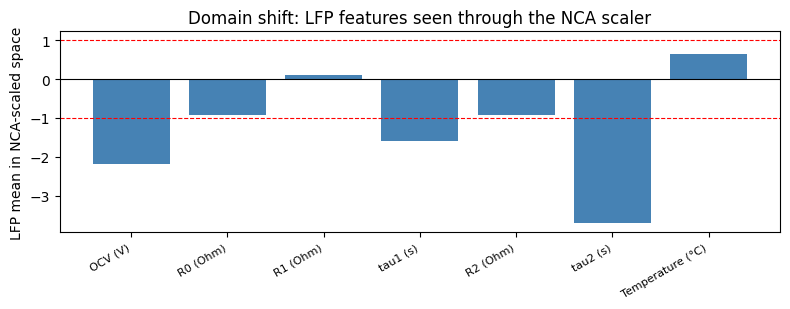

In [6]:
# ==================== 清洗 + 与 NCA 相同的特征工程 ====================
for col in list(dict.fromkeys(FEATURES + [TARGET] + LOG_TAU_COLS)):
    lfp_raw[col] = pd.to_numeric(
        lfp_raw[col].astype("string").str.strip().str.replace(",", ".", regex=False),
        errors="coerce")

lfp = lfp_raw.dropna(subset=list(dict.fromkeys(FEATURES + [TARGET]))).copy().reset_index(drop=True)

if USE_LOG_TAU:                      # 与 NCA 一致：tau 取自然对数
    for c in LOG_TAU_COLS:
        if (lfp[c] <= 0).any():
            raise ValueError(f"{c} 存在非正值，无法取 log，请检查 LFP 拟合结果。")
        lfp[c] = np.log(lfp[c])

X_lfp = lfp[FEATURES].values.astype(np.float32)
y_lfp = lfp[TARGET].values.astype(np.float32)
g_lfp = lfp["cell_id"].values

print(f"清洗后 N = {len(lfp)} | 电池数 = {lfp['cell_id'].nunique()}")
print(f"SOH 范围: {y_lfp.min():.2f} ~ {y_lfp.max():.2f} %")

# ==================== 域偏移体检：用 NCA 的 scaler 看 LFP 落在哪 ====================
# 若 LFP 特征与 NCA 同分布，下面每列的均值应接近 0、标准差接近 1。
# 偏离越大，Zero-shot 越可能失败，也越能解释「为什么需要 fine-tune」。
Z = NCA_X_SCALER.transform(X_lfp)
shift = pd.DataFrame({
    "LFP mean (NCA坐标)": Z.mean(0),
    "LFP std (NCA坐标)": Z.std(0),
    "NCA mean(原始)": NCA_X_SCALER.mean_,
    "LFP mean(原始)": X_lfp.mean(0),
}, index=FEATURES)
print("\n📐 域偏移体检（NCA 标准化坐标下的 LFP 分布）：")
print(shift.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(range(len(FEATURES)), shift["LFP mean (NCA坐标)"], color="steelblue")
ax.axhline(0, color="k", lw=0.8)
ax.axhline(1, color="r", ls="--", lw=0.8); ax.axhline(-1, color="r", ls="--", lw=0.8)
ax.set_xticks(range(len(FEATURES))); ax.set_xticklabels(FEATURES, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("LFP mean in NCA-scaled space")
ax.set_title("Domain shift: LFP features seen through the NCA scaler")
plt.tight_layout(); plt.show()


## 4. 固定 LFP 划分 + 标签预算抽样

按 `cell_id` 分组划分，同一块电池只会出现在 train / val / test 之一。
划分一旦定下来就**不再重算**，Zero-shot 只用其中的 test 部分。

```text
全部 LFP 电池
├── 测试池 TE_CELLS   20%  ← 固定，四种方法 + 所有标签量共用，永不改动
├── 验证池 VA_CELLS   10%  ← 固定，只用于早停
└── 训练池 POOL_CELLS 70%
     └── TR_CELLS     ← 从训练池随机抽 N_TRAIN_CELLS 块，这才是真正的训练集
```

| 方法 | 训练电池 | 验证电池 | 测试电池 |
|---|---|---|---|
| Zero-shot | 不训练 | 不使用 | `TE_CELLS` |
| Head-only | `TR_CELLS` | `VA_CELLS` | `TE_CELLS` |
| Full fine-tune | `TR_CELLS` | `VA_CELLS` | `TE_CELLS` |
| Scratch | `TR_CELLS` | `VA_CELLS` | `TE_CELLS` |

**两条纪律**：

1. `lfp_x_scaler` / `lfp_y_scaler` 只在 `TR_CELLS` 这 N 块上 fit，**不能碰训练池里没抽中的电池**
   —— 否则等于偷偷用了预算外的信息，构成泄露，标签效率曲线就没意义了。
2. 抽样按 `cell_id` 抽，不能按样本行抽。按行抽的话同一块电池的部分循环仍在训练集里，
   等于没削减。


In [7]:
n = len(X_lfp)
all_idx = np.arange(n)

if SPLIT_BY_CELL:
    gss1 = GroupShuffleSplit(n_splits=1, test_size=LFP_TEST_RATIO, random_state=SPLIT_SEED)
    tv_rel, te_rel = next(gss1.split(all_idx, groups=g_lfp))
    tv_idx, te_idx = all_idx[tv_rel], np.sort(all_idx[te_rel])

    inner_val = LFP_VAL_RATIO / max(1e-9, 1.0 - LFP_TEST_RATIO)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=inner_val, random_state=SPLIT_SEED + 1)
    pool_rel, va_rel = next(gss2.split(tv_idx, groups=g_lfp[tv_idx]))
    pool_idx, va_idx = np.sort(tv_idx[pool_rel]), np.sort(tv_idx[va_rel])
else:
    rng = np.random.default_rng(SPLIT_SEED)
    perm = rng.permutation(n)
    n_te, n_va = int(round(n * LFP_TEST_RATIO)), int(round(n * LFP_VAL_RATIO))
    te_idx, va_idx, pool_idx = (np.sort(perm[:n_te]), np.sort(perm[n_te:n_te + n_va]),
                                np.sort(perm[n_te + n_va:]))

POOL_CELLS = sorted(map(str, set(g_lfp[pool_idx])))   # 训练池（可抽样），不是训练集
VA_CELLS   = sorted(map(str, set(g_lfp[va_idx])))
TE_CELLS   = sorted(map(str, set(g_lfp[te_idx])))

# ==================== 标签预算：从训练池里抽 N_TRAIN_CELLS 块 ====================
if N_TRAIN_CELLS is None or N_TRAIN_CELLS >= len(POOL_CELLS):
    TR_CELLS = list(POOL_CELLS)
else:
    _rng = np.random.default_rng(BUDGET_SEED)
    TR_CELLS = sorted(map(str, _rng.permutation(np.array(POOL_CELLS))[:N_TRAIN_CELLS]))

tr_idx = pool_idx[np.isin(g_lfp[pool_idx], TR_CELLS)]

X_tr, y_tr = X_lfp[tr_idx], y_lfp[tr_idx]
X_va, y_va = X_lfp[va_idx], y_lfp[va_idx]
X_te, y_te = X_lfp[te_idx], y_lfp[te_idx]

if SPLIT_BY_CELL:
    assert set(POOL_CELLS).isdisjoint(TE_CELLS) and set(VA_CELLS).isdisjoint(TE_CELLS) \
           and set(POOL_CELLS).isdisjoint(VA_CELLS), "❌ 电池在集合间重叠！"
    assert set(TR_CELLS).issubset(POOL_CELLS), "❌ 训练电池不在训练池内！"

print(f"🔋 电池数  训练池/验证/测试 = {len(POOL_CELLS)} / {len(VA_CELLS)} / {len(TE_CELLS)}")
print(f"💰 标签预算 实际训练电池   = {len(TR_CELLS)} 块（占训练池 {len(TR_CELLS)/len(POOL_CELLS):.1%}）")
print(f"📊 样本量  train/val/test  = {len(tr_idx)} / {len(va_idx)} / {len(te_idx)}")
def _brief(cs, k=8):
    return ", ".join(cs[:k]) + (f" … (共 {len(cs)} 块)" if len(cs) > k else "")

print(f"🔒 测试电池（所有实验完全相同）：{_brief(TE_CELLS)}")
print(f"🎯 本次训练电池：{_brief(TR_CELLS, 20)}")

# ==================== 两套 scaler ====================
# LFP scaler 只在"被预算选中的那 N 块"上 fit
#   —— 不能用整个训练池，否则等于用了预算外的信息（泄露）
lfp_x_scaler = StandardScaler().fit(X_tr)
lfp_y_scaler = StandardScaler().fit(y_tr.reshape(-1, 1))

SCALERS = {"nca": NCA_X_SCALER, "lfp": lfp_x_scaler}

def get_inputs(scaler_key):
    """按方法的 scaler 策略返回标准化后的 (train, val, test)。"""
    xs = SCALERS[scaler_key]
    return xs.transform(X_tr), xs.transform(X_va), xs.transform(X_te)

print("\n✅ scaler 就绪：NCA scaler（Zero-shot / Head-only）+ LFP 训练集 scaler（Full FT / Scratch）")


🔋 电池数  训练池/验证/测试 = 140 / 21 / 41
💰 标签预算 实际训练电池   = 5 块（占训练池 3.6%）
📊 样本量  train/val/test  = 49687 / 142544 / 290721
🔒 测试电池（所有实验完全相同）：A123_016_70SOC_60DOD, A123_022_30SOC_60DOD, A123_023_30SOC_60DOD, A123_025_30SOC_60DOD, A123_059_70SOC_60DOD, A123_075_30SOC_60DOD, A123_085_50SOC_20DOD, A123_086_50SOC_20DOD … (共 41 块)
🎯 本次训练电池：A123_065_70SOC_20DOD, A123_130_90SOC_20DOD, A123_173_50SOC_20DOD, A123_192_70SOC_20DOD, A123_217_70SOC_20DOD

✅ scaler 就绪：NCA scaler（Zero-shot / Head-only）+ LFP 训练集 scaler（Full FT / Scratch）


## 5. 训练与评估工具

三个容易被忽略、但会直接改变结论的实现细节：

1. **BatchNorm 也属于 \(\phi\)**。Head-only 若只做 `requires_grad=False`，BN 的 running mean/var
   仍会在 `model.train()` 下被 LFP 数据更新——那就不是「冻结特征提取器」了。
   这里在训练时对 `model.feature` 单独调 `.eval()`，保证 \(\phi\) 一个数都不动。
2. **早停只看验证集**。测试集标签自始至终只出现在最后一步的指标计算里。
3. **batch size 必须随样本量自适应**。只训 5 块电池时样本可能只有几百条，若沿用
   `bs=1024`，一个 epoch 只有 1 步梯度更新，`EPOCHS=200` 就只有 200 步。
   Head-only 只有 33 个参数，几十步足够收敛；Scratch 有 11841 个参数，200 步远远不够。
   这时测到的 \(\Delta R^2\) 不是「迁移有效」，而是「Scratch 被人为饿死了」。
   `adaptive_bs()` 保证每个 epoch 至少 `TARGET_STEPS_PER_EPOCH` 步，让对照公平。

> ⚠️ 注意 `make_loader` 的默认参数不能写成 `bs=BATCH_SIZE`：Python 的默认值在**函数定义时**
> 就绑定了，之后再改全局 `BATCH_SIZE` 不会生效。这里改成读全局 `CUR_BS`。


In [8]:
def adaptive_bs(n_rows, base=None, target_steps=TARGET_STEPS_PER_EPOCH, min_bs=MIN_BATCH):
    """让每个 epoch 至少有 target_steps 步梯度更新，向下取到 2 的幂。

    小样本时若沿用 bs=1024，一个 epoch 只有 1 步，Scratch 根本没收敛就被早停，
    测出来的迁移增益是假的。这是小样本对照实验里最容易犯的错。
    """
    base = BATCH_SIZE if base is None else base
    want = max(min_bs, n_rows / target_steps)
    return int(np.clip(2 ** int(np.floor(np.log2(want))), min_bs, base))


CUR_BS = adaptive_bs(len(X_tr))     # 全局当前 batch size，随训练子集大小变化


def make_loader(Xs, ys, bs=None, shuffle=False):
    # 不能写成 bs=BATCH_SIZE：默认值在函数定义时绑定，之后改全局无效
    bs = CUR_BS if bs is None else bs
    ds = TensorDataset(torch.tensor(Xs, dtype=torch.float32),
                       torch.tensor(ys, dtype=torch.float32).view(-1, 1))
    # BatchNorm 在训练模式下遇到长度为 1 的尾批会报错，只有这种情况才丢尾批
    drop_last = shuffle and len(ds) > bs and (len(ds) % bs == 1)
    return DataLoader(ds, batch_size=bs, shuffle=shuffle, drop_last=drop_last)


def train_model(Xtr_s, ytr_s, Xva_s, yva_s, seed=42, init_state=None, only_head=False,
                lr=1e-3, epochs=EPOCHS, patience=PATIENCE, weight_decay=WEIGHT_DECAY,
                verbose=False):
    """训练单个模型。

    init_state=None  → 随机初始化（Scratch）
    init_state=NCA权重 → 从 NCA 解出发（Head-only / Full fine-tune）
    only_head=True   → 冻结 feature（含 BatchNorm 统计量），只更新 head
    """
    torch.manual_seed(seed)
    model = SOHNet(in_dim=IN_DIM, hidden=HIDDEN, p_drop=P_DROP).to(device)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))

    if only_head:
        for p in model.feature.parameters():
            p.requires_grad = False
        params = model.head.parameters()
    else:
        params = model.parameters()

    opt = torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
    loss_fn = nn.MSELoss()

    tl = make_loader(Xtr_s, ytr_s, shuffle=True)
    vl = make_loader(Xva_s, yva_s)

    best, best_state, wait = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for ep in range(epochs):
        model.train()
        if only_head:
            model.feature.eval()        # 关键：冻住 BatchNorm 的 running stats 和 Dropout
        tr_loss = 0.0
        for xb, yb in tl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            tr_loss += loss.item() * len(xb)
        tr_loss /= max(1, len(tl.dataset))

        model.eval()
        v = 0.0
        with torch.no_grad():
            for xb, yb in vl:
                xb, yb = xb.to(device), yb.to(device)
                v += loss_fn(model(xb), yb).item() * len(xb)
        v /= max(1, len(vl.dataset))

        sched.step(v)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(v)
        if verbose and ep % 20 == 0:
            print(f"    seed={seed} ep={ep:3d} train={tr_loss:.4f} val={v:.4f} "
                  f"lr={opt.param_groups[0]['lr']:.2e}")

        if v < best - 1e-6:
            best, wait = v, 0
            best_state = {k: t.detach().cpu().clone() for k, t in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.history = history
    model.best_val = best
    return model


def predict_ensemble(models_or_states, Xs, y_scaler, bs=65536):
    """集成预测 → (均值, 跨模型标准差)，都已反标准化回 SOH(%)。
       传入 state_dict 列表时会临时建模型（Zero-shot 用）。"""
    preds = []
    for item in models_or_states:
        if isinstance(item, dict):
            m = SOHNet(in_dim=IN_DIM, hidden=HIDDEN, p_drop=P_DROP).to(device)
            m.load_state_dict(item)
        else:
            m = item
        m.eval()
        out = []
        with torch.no_grad():
            for i in range(0, len(Xs), bs):
                xb = torch.tensor(Xs[i:i + bs], dtype=torch.float32).to(device)
                out.append(m(xb).cpu().numpy().ravel())
        p = np.concatenate(out)
        preds.append(y_scaler.inverse_transform(p.reshape(-1, 1)).ravel())
    P = np.stack(preds)
    return P.mean(0), P.std(0)


def metrics_of(y_true, y_pred):
    return dict(
        rmse=float(np.sqrt(mean_squared_error(y_true, y_pred))),
        mae=float(mean_absolute_error(y_true, y_pred)),
        r2=float(r2_score(y_true, y_pred)),
        mape=float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
    )


def report(name, y_true, y_pred):
    m = metrics_of(y_true, y_pred)
    print(f"[{name:16s}] RMSE={m['rmse']:6.3f}  MAE={m['mae']:6.3f}  "
          f"R2={m['r2']:7.4f}  MAPE={m['mape']:5.2f}%")
    return m


RESULTS = {}     # method -> dict(metrics, y_pred, y_std, models, seconds)


def run_experiment(name, init_states=None, only_head=False, lr=1e-3,
                   scaler_key=None, seeds=SEEDS, epochs=EPOCHS, patience=PATIENCE,
                   weight_decay=WEIGHT_DECAY, verbose=True, store=True, quiet=False):
    """跑一种迁移方法：训练 K 个成员 → 集成预测 → 评估 train/val/test。"""
    scaler_key = scaler_key or SCALER_POLICY[name]
    Xtr_s, Xva_s, Xte_s = get_inputs(scaler_key)
    ytr_s = lfp_y_scaler.transform(y_tr.reshape(-1, 1)).ravel()
    yva_s = lfp_y_scaler.transform(y_va.reshape(-1, 1)).ravel()

    t0 = time.time()
    models = []
    for i, s in enumerate(seeds):
        init = None if init_states is None else init_states[i % len(init_states)]
        models.append(train_model(Xtr_s, ytr_s, Xva_s, yva_s, seed=s, init_state=init,
                                  only_head=only_head, lr=lr, epochs=epochs,
                                  patience=patience, weight_decay=weight_decay,
                                  verbose=verbose))
    secs = time.time() - t0

    mu_tr, _ = predict_ensemble(models, Xtr_s, lfp_y_scaler)
    mu_va, _ = predict_ensemble(models, Xva_s, lfp_y_scaler)
    mu_te, sd_te = predict_ensemble(models, Xte_s, lfp_y_scaler)

    m_tr, m_va, m_te = metrics_of(y_tr, mu_tr), metrics_of(y_va, mu_va), metrics_of(y_te, mu_te)
    n_trainable = sum(p.numel() for p in models[0].parameters() if p.requires_grad)

    if quiet:
        print(f"    {name:16s} test R2={m_te['r2']:7.4f}  RMSE={m_te['rmse']:6.3f}")
    else:
        print(f"\n===== {name} =====")
        print(f"  可训练参数 = {n_trainable} | 输入 scaler = {scaler_key} | lr = {lr:g} | "
              f"bs = {CUR_BS} ({int(np.ceil(len(X_tr)/CUR_BS))} 步/epoch) | "
              f"耗时 {secs:.1f}s | 平均停在 epoch {np.mean([len(m.history['val_loss']) for m in models]):.0f}")
        report(f"{name} train", y_tr, mu_tr)
        report(f"{name} val", y_va, mu_va)
        report(f"{name} TEST", y_te, mu_te)

    out = dict(name=name, test=m_te, train=m_tr, val=m_va, y_pred=mu_te, y_std=sd_te,
               models=models, seconds=secs, n_trainable=n_trainable,
               scaler=scaler_key, lr=lr)
    if store:
        RESULTS[name] = out
    return out


print(f"✅ 训练 / 评估工具就绪 | 训练样本 {len(X_tr)} 行 → CUR_BS = {CUR_BS} "
      f"({int(np.ceil(len(X_tr)/CUR_BS))} 步/epoch)")


✅ 训练 / 评估工具就绪 | 训练样本 49687 行 → CUR_BS = 1024 (49 步/epoch)


## 实验 1 — Zero-shot：直接迁移，不训练

模型参数完全保持 \(\theta_{NCA}\) 不变：

\[
\hat{y}_{LFP}=f_{\theta_{NCA}}(x_{LFP})
\]

数据流：

```text
LFP 原始特征 → 与 NCA 相同的特征工程（tau 取 log）
             → NCA 的输入 scaler → NCA 模型
             → NCA 的输出 scaler 反变换 → LFP 预测 SOH
```

LFP 测试标签**只用于最后算 RMSE / MAE / R² / MAPE**，不参与拟合 scaler、不参与选 epoch。

额外附一个 **Zero-shot + 线性校正**：在 LFP 训练集上拟合 \(\hat{y}'=a\hat{y}+b\)。
它专门用来区分两件事——如果校正后就大幅变好，说明 NCA 的排序能力是对的、差的只是尺度和偏置；
如果校正后仍然差，说明是特征—SOH 关系本身不通用。


===== Zero-shot（不更新任何参数）=====
[Zero-shot TEST  ] RMSE=12.107  MAE=10.592  R2=-1.8802  MAPE=11.85%
集成平均不确定度 = 1.463 SOH%

线性校正参数（LFP 训练集拟合）: y ≈ 0.1117·ŷ + 79.1406
[Zero-shot+cal TEST] RMSE= 6.439  MAE= 5.008  R2= 0.1852  MAPE= 5.88%


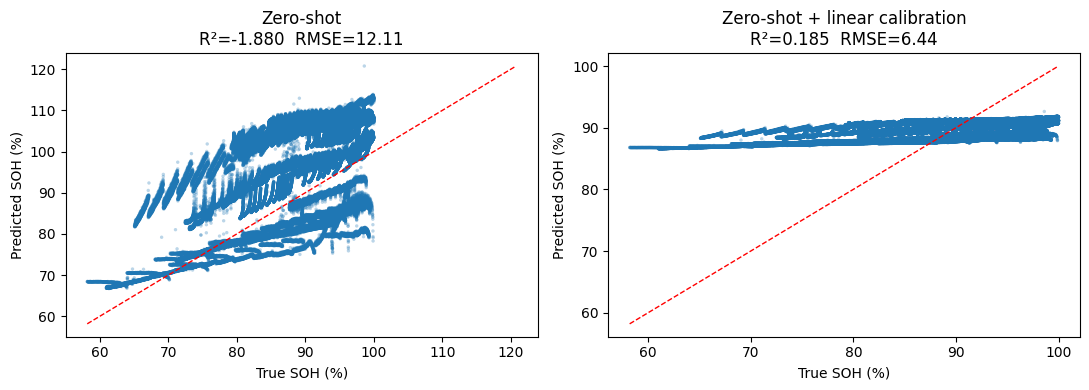

In [9]:
# ---- Zero-shot：使用 NCA 的输入 scaler 和 NCA 的输出 scaler ----
Xte_s_nca = NCA_X_SCALER.transform(X_te)
mu_zs, sd_zs = predict_ensemble(NCA_STATES, Xte_s_nca, NCA_Y_SCALER)

print("===== Zero-shot（不更新任何参数）=====")
m_zs = report("Zero-shot TEST", y_te, mu_zs)
print(f"集成平均不确定度 = {sd_zs.mean():.3f} SOH%")

RESULTS["Zero-shot"] = dict(name="Zero-shot", test=m_zs, train=None, val=None,
                            y_pred=mu_zs, y_std=sd_zs, models=None, seconds=0.0,
                            n_trainable=0, scaler="nca", lr=0.0)

# ---- 附加诊断：Zero-shot + 线性校正（a·ŷ+b，仅用 LFP 训练集拟合）----
Xtr_s_nca = NCA_X_SCALER.transform(X_tr)
mu_zs_tr, _ = predict_ensemble(NCA_STATES, Xtr_s_nca, NCA_Y_SCALER)
a, b = np.polyfit(mu_zs_tr, y_tr, 1)
mu_zs_cal = a * mu_zs + b

print(f"\n线性校正参数（LFP 训练集拟合）: y ≈ {a:.4f}·ŷ + {b:.4f}")
m_zs_cal = report("Zero-shot+cal TEST", y_te, mu_zs_cal)
RESULTS["Zero-shot+cal"] = dict(name="Zero-shot+cal", test=m_zs_cal, train=None, val=None,
                                y_pred=mu_zs_cal, y_std=sd_zs, models=None, seconds=0.0,
                                n_trainable=2, scaler="nca", lr=0.0)

# ---- 偏置诊断图 ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (mu_, ttl) in zip(axes, [(mu_zs, "Zero-shot"), (mu_zs_cal, "Zero-shot + linear calibration")]):
    ax.scatter(y_te, mu_, s=6, alpha=0.3, edgecolors="none")
    lo, hi = float(min(y_te.min(), mu_.min())), float(max(y_te.max(), mu_.max()))
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)
    ax.set_xlabel("True SOH (%)"); ax.set_ylabel("Predicted SOH (%)")
    ax.set_title(f"{ttl}\nR²={r2_score(y_te, mu_):.3f}  "
                 f"RMSE={np.sqrt(mean_squared_error(y_te, mu_)):.2f}")
plt.tight_layout(); plt.show()


## 实验 2 — Head-only：冻结 feature，只训练 head

\[
\hat{y}_{LFP}=g_{\psi_{LFP}}\!\left(h_{\phi_{NCA}}(x_{LFP})\right),\qquad \phi_{LFP}=\phi_{NCA}
\]

前向传播走完整网络，反向传播只更新 head：

```text
前向：输入 → feature → 32 维隐藏特征 → head → 输出
反向：损失 → head 参数（梯度到 feature 处停止）
```

可训练参数只有 \(32\times1+1=33\) 个，所以在 LFP 样本少的时候不容易过拟合。
它问的是：**能不能只靠重新映射那 32 维特征，就把 LFP 的 SOH 学出来？**


In [10]:
head_only = run_experiment("Head-only", init_states=NCA_STATES, only_head=True,
                           lr=HEAD_LR, verbose=True)

# 确认 feature 确实一个数都没动（含 BatchNorm 的 running stats）
m0 = head_only["models"][0].state_dict()
ref = NCA_STATES[0]
max_diff = max(float((m0[k].cpu() - ref[k].cpu()).abs().max())
               for k in ref if k.startswith("feature") and ref[k].is_floating_point())
print(f"\n🔍 feature 参数最大变化量 = {max_diff:.3e}（应为 0，说明 φ 被真正冻结）")


    seed=42 ep=  0 train=3.7344 val=2.1889 lr=1.00e-03
    seed=42 ep= 20 train=0.7042 val=1.2678 lr=1.00e-03
    seed=42 ep= 40 train=0.5856 val=1.0163 lr=1.00e-03
    seed=42 ep= 60 train=0.5045 val=1.0547 lr=2.50e-04
    seed=2024 ep=  0 train=4.6054 val=2.8490 lr=1.00e-03
    seed=2024 ep= 20 train=0.6833 val=1.1332 lr=1.00e-03
    seed=2024 ep= 40 train=0.4974 val=0.8631 lr=1.00e-03
    seed=2024 ep= 60 train=0.3824 val=0.8722 lr=2.50e-04
    seed=9999 ep=  0 train=3.9341 val=2.2200 lr=1.00e-03
    seed=9999 ep= 20 train=0.6463 val=1.4041 lr=1.00e-03
    seed=9999 ep= 40 train=0.4826 val=1.1884 lr=1.00e-03
    seed=9999 ep= 60 train=0.3799 val=1.0851 lr=1.00e-03
    seed=9999 ep= 80 train=0.3285 val=1.0803 lr=2.50e-04

===== Head-only =====
  可训练参数 = 33 | 输入 scaler = nca | lr = 0.001 | bs = 1024 (49 步/epoch) | 耗时 343.3s | 平均停在 epoch 75
[Head-only train ] RMSE= 2.671  MAE= 2.077  R2= 0.5830  MAPE= 2.29%
[Head-only val   ] RMSE= 3.706  MAE= 2.981  R2= 0.6686  MAPE= 3.38%
[Head-only 

## 实验 3 — Full fine-tune：从 NCA 参数出发，训练整个网络

初始化 \(\theta_{LFP}^{(0)}=\theta_{NCA}\)，然后全部参数参与优化：

\[
\theta_{LFP}^{(t+1)}=\theta_{LFP}^{(t)}-\eta_{small}\nabla_\theta L_{LFP}
\]

它不是从随机参数开始，而是**在 NCA 的解附近找一个更适合 LFP 的解**。
所以学习率必须小（这里 \(10^{-4}\)）：学习率一大，NCA 学到的东西会在前几个 epoch 内被冲掉，
结果就退化成一个「初始化比较奇怪的 Scratch」。


In [11]:
full_ft = run_experiment("Full fine-tune", init_states=NCA_STATES, only_head=False,
                         lr=FULL_LR, verbose=True)

# 微调后参数离 NCA 有多远？变化越大说明 LFP 越需要重塑特征
m0 = full_ft["models"][0].state_dict()
ref = NCA_STATES[0]
rows = []
for k in ref:
    if not ref[k].is_floating_point():
        continue
    d = float((m0[k].cpu() - ref[k].cpu()).norm())
    base = float(ref[k].cpu().norm()) + 1e-12
    rows.append((k, d, d / base))
drift = pd.DataFrame(rows, columns=["param", "L2 变化量", "相对变化"]).set_index("param")
print("\n🔍 Full fine-tune 后各层参数相对 NCA 的漂移：")
print(drift.round(4).to_string())


    seed=42 ep=  0 train=0.5662 val=1.1417 lr=1.00e-04
    seed=42 ep= 20 train=0.1085 val=1.1204 lr=2.50e-05
    seed=2024 ep=  0 train=0.6313 val=1.2943 lr=1.00e-04
    seed=2024 ep= 20 train=0.1243 val=1.1333 lr=2.50e-05
    seed=9999 ep=  0 train=0.5830 val=1.1867 lr=1.00e-04
    seed=9999 ep= 20 train=0.0952 val=1.1444 lr=5.00e-05

===== Full fine-tune =====
  可训练参数 = 11841 | 输入 scaler = lfp | lr = 0.0001 | bs = 1024 (49 步/epoch) | 耗时 122.9s | 平均停在 epoch 27
[Full fine-tune train] RMSE= 1.344  MAE= 0.991  R2= 0.8944  MAPE= 1.09%
[Full fine-tune val] RMSE= 3.966  MAE= 3.042  R2= 0.6205  MAPE= 3.55%
[Full fine-tune TEST] RMSE= 4.934  MAE= 3.737  R2= 0.5216  MAPE= 4.40%

🔍 Full fine-tune 后各层参数相对 NCA 的漂移：
                        L2 变化量     相对变化
param                                  
feature.0.weight        0.3007   0.0650
feature.0.bias          0.0000  10.8998
feature.1.weight        0.1031   0.0154
feature.1.bias          0.0972   0.0333
feature.1.running_mean  0.0127   1.8309
featu

## 实验 4 — Scratch：完全从零训练（最重要的基线）

\[
\theta_{LFP}^{(0)}\sim\text{Random Initialization},\qquad
\theta_{LFP}=\arg\min_\theta L_{LFP}
\]

结构一样、数据一样、划分一样，只是**不加载任何 NCA 权重**。
Scratch 不是为了当最终模型，而是为了让下面这两个差值有意义：

\[
R^2_{Head\text{-}only}-R^2_{Scratch},\qquad R^2_{Full}-R^2_{Scratch}
\]

差值为正，才谈得上「迁移学习带来了收益」。


    seed=42 ep=  0 train=0.2978 val=1.4126 lr=2.00e-03
    seed=42 ep= 20 train=0.0493 val=1.6935 lr=2.50e-04
    seed=2024 ep=  0 train=0.3484 val=1.1943 lr=2.00e-03
    seed=2024 ep= 20 train=0.0505 val=1.8434 lr=2.50e-04
    seed=9999 ep=  0 train=0.3071 val=1.6416 lr=2.00e-03
    seed=9999 ep= 20 train=0.0461 val=1.9840 lr=2.50e-04

===== Scratch =====
  可训练参数 = 11841 | 输入 scaler = lfp | lr = 0.002 | bs = 1024 (49 步/epoch) | 耗时 96.1s | 平均停在 epoch 21
[Scratch train   ] RMSE= 1.360  MAE= 1.012  R2= 0.8919  MAPE= 1.12%
[Scratch val     ] RMSE= 4.841  MAE= 3.452  R2= 0.4348  MAPE= 4.02%
[Scratch TEST    ] RMSE= 5.955  MAE= 4.478  R2= 0.3031  MAPE= 5.30%


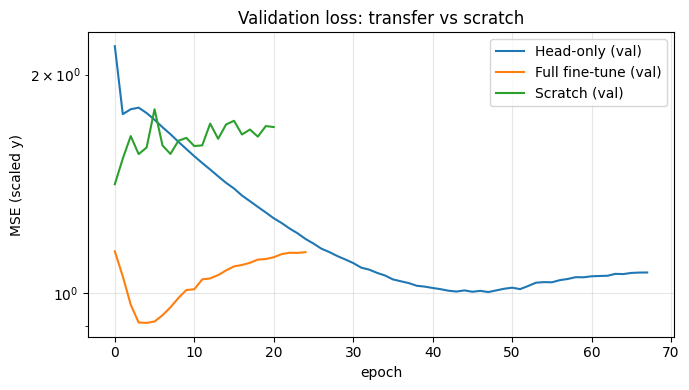

In [12]:
scratch = run_experiment("Scratch", init_states=None, only_head=False,
                         lr=SCRATCH_LR, verbose=True)

# 四种方法的收敛曲线对照（各取第一个成员）
fig, ax = plt.subplots(figsize=(7, 4))
for name in ["Head-only", "Full fine-tune", "Scratch"]:
    h = RESULTS[name]["models"][0].history
    ax.plot(h["val_loss"], label=f"{name} (val)")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE (scaled y)")
ax.set_yscale("log"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Validation loss: transfer vs scratch")
plt.tight_layout(); plt.show()


## 6. 汇总对比

同一批测试电池、同一套划分，唯一的区别就是初始化方式与可训练参数集合。
下面同时看 R²、RMSE、MAE——**不能只看 R²**，三者应当同向变化，否则说明结果不稳。


📊 NCA → LFP 迁移学习四组对照（测试集完全相同）
        method   init  updated  n_trainable scaler  test_r2  test_rmse  test_mae  test_mape  train_r2  val_r2  seconds
     Zero-shot    NCA        无            0    nca  -1.8802    12.1066   10.5925    11.8450       NaN     NaN      0.0
 Zero-shot+cal    NCA    仅 a,b            2    nca   0.1852     6.4393    5.0079     5.8848       NaN     NaN      0.0
     Head-only    NCA ψ (head)           33    nca   0.5100     4.9936    3.8137     4.3602    0.5830  0.6686    343.3
Full fine-tune    NCA      φ+ψ        11841    lfp   0.5216     4.9339    3.7371     4.3969    0.8944  0.6205    122.9
       Scratch Random      φ+ψ        11841    lfp   0.3031     5.9551    4.4781     5.2953    0.8919  0.4348     96.1

🔬 相对 Scratch 基线的收益（正=迁移有收益）：
   Zero-shot        ΔR²=-2.1833 | ΔRMSE=+6.1514 | ΔMAE=+6.1144
   Head-only        ΔR²=+0.2069 | ΔRMSE=-0.9615 | ΔMAE=-0.6645
   Full fine-tune   ΔR²=+0.2185 | ΔRMSE=-1.0212 | ΔMAE=-0.7410


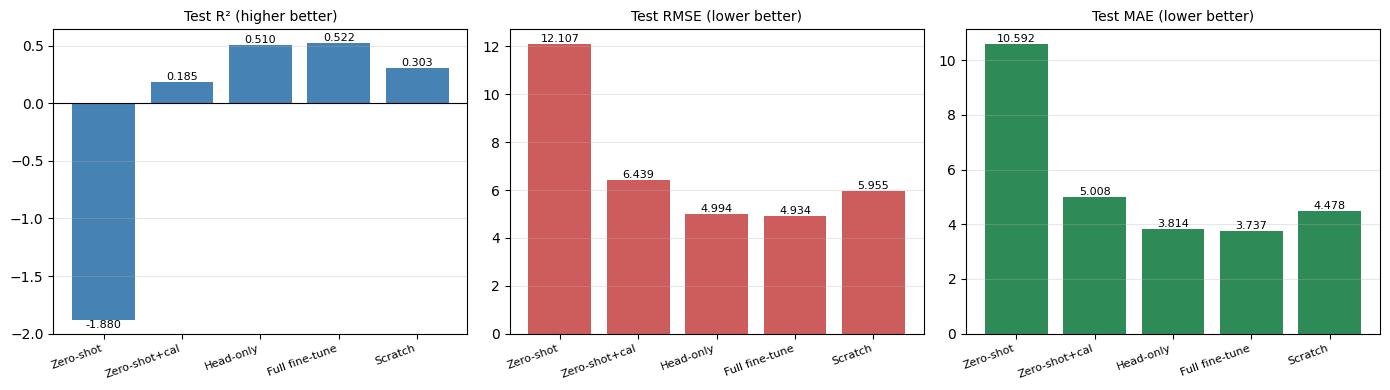

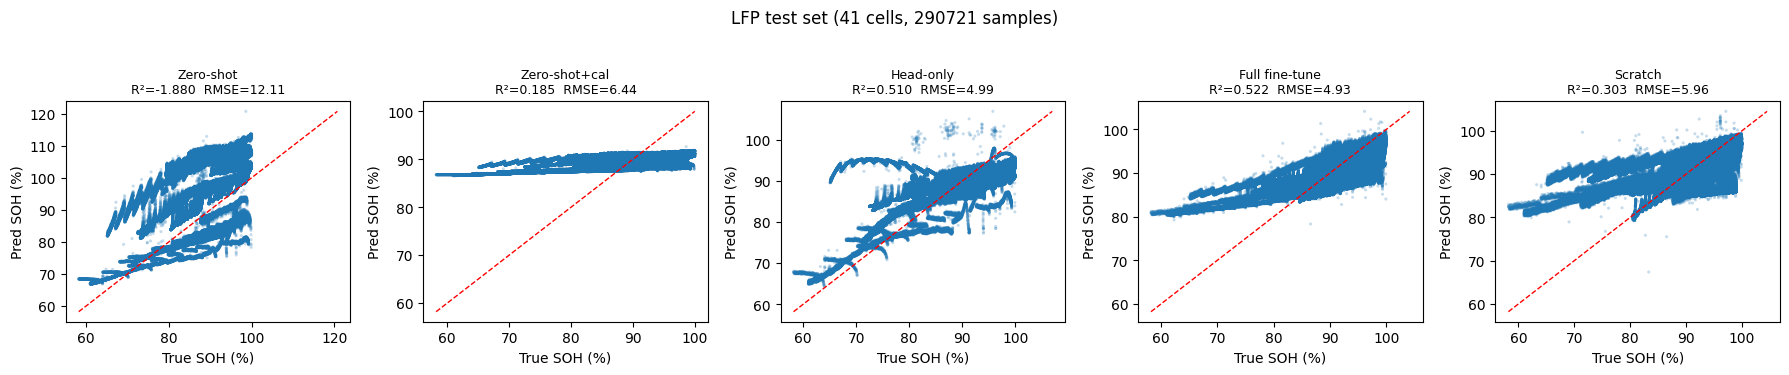


💾 已保存：transfer_results\transfer_summary.csv 与 transfer_results\transfer_test_predictions.csv


In [13]:
ORDER = ["Zero-shot", "Zero-shot+cal", "Head-only", "Full fine-tune", "Scratch"]
rows = []
for k in ORDER:
    if k not in RESULTS:
        continue
    r = RESULTS[k]
    rows.append(dict(
        method=k,
        init="NCA" if k != "Scratch" else "Random",
        updated={"Zero-shot": "无", "Zero-shot+cal": "仅 a,b",
                 "Head-only": "ψ (head)", "Full fine-tune": "φ+ψ", "Scratch": "φ+ψ"}[k],
        n_trainable=r["n_trainable"], scaler=r["scaler"],
        test_r2=r["test"]["r2"], test_rmse=r["test"]["rmse"],
        test_mae=r["test"]["mae"], test_mape=r["test"]["mape"],
        train_r2=(r["train"]["r2"] if r["train"] else np.nan),
        val_r2=(r["val"]["r2"] if r["val"] else np.nan),
        seconds=round(r["seconds"], 1),
    ))

summary = pd.DataFrame(rows)
summary.to_csv(RESULT_DIR / "transfer_summary.csv", index=False)

print("📊 NCA → LFP 迁移学习四组对照（测试集完全相同）")
print(summary.round(4).to_string(index=False))

# ---- 迁移收益 ----
if "Scratch" in RESULTS:
    base = RESULTS["Scratch"]["test"]
    print("\n🔬 相对 Scratch 基线的收益（正=迁移有收益）：")
    for k in ["Zero-shot", "Head-only", "Full fine-tune"]:
        if k not in RESULTS:
            continue
        t = RESULTS[k]["test"]
        print(f"   {k:16s} ΔR²={t['r2']-base['r2']:+.4f} | "
              f"ΔRMSE={t['rmse']-base['rmse']:+.4f} | ΔMAE={t['mae']-base['mae']:+.4f}")

# ---- 柱状图 ----
plot_keys = [k for k in ORDER if k in RESULTS]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric, ttl, color in zip(
        axes, ["r2", "rmse", "mae"],
        ["Test R² (higher better)", "Test RMSE (lower better)", "Test MAE (lower better)"],
        ["steelblue", "indianred", "seagreen"]):
    vals = [RESULTS[k]["test"][metric] for k in plot_keys]
    ax.bar(range(len(plot_keys)), vals, color=color)
    ax.set_xticks(range(len(plot_keys)))
    ax.set_xticklabels(plot_keys, rotation=20, ha="right", fontsize=8)
    ax.set_title(ttl, fontsize=10); ax.grid(axis="y", alpha=0.3)
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.3f}", ha="center",
                va="bottom" if v >= 0 else "top", fontsize=8)
    if metric == "r2":
        ax.axhline(0, color="k", lw=0.8)
plt.tight_layout(); plt.show()

# ---- 预测散点墙 ----
ncol = len(plot_keys)
fig, axes = plt.subplots(1, ncol, figsize=(3.6 * ncol, 3.6), squeeze=False)
for ax, k in zip(axes.ravel(), plot_keys):
    yp = RESULTS[k]["y_pred"]
    ax.scatter(y_te, yp, s=5, alpha=0.25, edgecolors="none")
    lo = float(min(y_te.min(), yp.min())); hi = float(max(y_te.max(), yp.max()))
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)
    ax.set_title(f"{k}\nR²={RESULTS[k]['test']['r2']:.3f}  "
                 f"RMSE={RESULTS[k]['test']['rmse']:.2f}", fontsize=9)
    ax.set_xlabel("True SOH (%)"); ax.set_ylabel("Pred SOH (%)")
fig.suptitle(f"LFP test set ({len(TE_CELLS)} cells, {len(te_idx)} samples)", y=1.03)
plt.tight_layout(); plt.show()

# ---- 逐样本预测存档 ----
pred_df = pd.DataFrame({"cell_id": g_lfp[te_idx], "y_true": y_te})
for k in plot_keys:
    pred_df[f"pred_{k}"] = RESULTS[k]["y_pred"]
pred_df.to_csv(RESULT_DIR / "transfer_test_predictions.csv", index=False)
print(f"\n💾 已保存：{RESULT_DIR/'transfer_summary.csv'} 与 {RESULT_DIR/'transfer_test_predictions.csv'}")


## 7. 标签效率曲线：LFP 训练数据给多少才够

第 6 节只回答了「在 `N_TRAIN_CELLS` 这一个预算下谁赢」。真正要回答的问题是
**「要标注多少块 LFP 电池才值得」**，这需要把训练电池数当成自变量扫一遍。

从训练池里按 \(N\) 块抽样重跑 Head-only / Full fine-tune / Scratch，
测试集与验证集始终不变，唯一变化的是训练标签量。

### 四条实现纪律

| 纪律 | 为什么 |
|---|---|
| **对数网格** \(N\in\{1,2,3,5,8,13,21,34,55,90,140\}\) | 迁移增益在 \(\log N\) 上近似线性衰减；线性网格（10%/25%/50%/100%）会完全错过增益最大的 \(N\le 8\) 区间 |
| **嵌套子集** | 每个 repeat 只生成一次全排列取前 \(N\) 个，使 \(N{=}2\) 的集合是 \(N{=}4\) 的子集。否则曲线抖动里混进了「抽样差异」，不再是纯粹的「数据量差异」 |
| **重复抽样** | \(N{=}1\) 时抽到哪块电池的影响远大于方法差异。不重复就没有误差带，无法区分「迁移有效」和「这次抽样运气好」 |
| **batch size 自适应 + scaler 只在子集上 fit** | 前者保证 Scratch 不被饿死，后者防止用到预算外信息造成泄露 |

### 三个判据（跑完自动计算）

\[
\textbf{1. 交叉点} N^*:\quad R^2_{\text{transfer}}(N^*)=R^2_{\text{scratch}}(N^*)
\]

\(N>N^*\) 时迁移不再有价值，直接从零训练即可 —— 这是「值不值得做迁移」的直接答案。

\[
\textbf{2. 等效标签量倍数}\quad \rho(N)=\frac{N_{\text{equiv}}(N)}{N}
\]

迁移用 \(N\) 块达到的 \(R^2\)，Scratch 需要 \(N_{\text{equiv}}\) 块才追平。
这是最能说服工程方的数字：「用 5 块做迁移 ≈ 从零训练用 30 块，省 6 倍测试机时」。

\[
\textbf{3. 噪声带}\quad \Delta R^2(N)\le\sqrt{\sigma^2_{\text{transfer}}+\sigma^2_{\text{scratch}}}
\]

增益落到重复抽样的噪声以下时，就不能再声称有收益。

### 验证集口径

- `VAL_POLICY="fixed"`：验证集始终用满 `VA_CELLS`（**乐观口径**，隔离了单一变量，推荐作主实验，但要在文中说明——它等于假设你有一个免费的大验证集用来早停）
- `VAL_POLICY="shrink"`：验证集按同比例缩减（**现实口径**，小样本时早停本身也不可靠，建议作附录对照）

> ⏱ 完整网格约 300 次模型训练。想先探路可把 `N_CELLS_GRID` 砍成 `[1, 3, 8, 21, 55, 140]`、
> `n_repeats_for` 统一返回 2。


训练池 140 块 | 验证 21 块 | 测试 41 块
网格 N = [1, 2, 3, 5, 8, 13, 21, 34, 55, 90, 140] | 验证集口径 = fixed

[N=  1 rep=0] 训练   9312 行 / 验证 142544 行 (21 块) | bs=512 → 19 步/epoch
    Head-only        test R2= 0.0172  RMSE= 7.072
    Full fine-tune   test R2=-3.4910  RMSE=15.117
    Scratch          test R2=-10.5563  RMSE=24.250
[N=  1 rep=1] 训练   5894 行 / 验证 142544 行 (21 块) | bs=256 → 24 步/epoch
    Head-only        test R2= 0.4011  RMSE= 5.520
    Full fine-tune   test R2=-41.6909  RMSE=46.610
    Scratch          test R2=-0.2391  RMSE= 7.941
[N=  1 rep=2] 训练  11755 行 / 验证 142544 行 (21 块) | bs=512 → 23 步/epoch
    Head-only        test R2=-0.0554  RMSE= 7.329
    Full fine-tune   test R2=-0.0964  RMSE= 7.470
    Scratch          test R2=-0.4637  RMSE= 8.631
[N=  1 rep=3] 训练   7741 行 / 验证 142544 行 (21 块) | bs=512 → 16 步/epoch
    Head-only        test R2= 0.3536  RMSE= 5.735
    Full fine-tune   test R2=-10.4092  RMSE=24.095
    Scratch          test R2=-3.4733  RMSE=15.088
[N=  1 rep=4] 训练  11240 行 

C:\Users\huang\AppData\Local\Temp\ipykernel_3608\2955843219.py:172: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huang\AppData\Local\Temp\ipykernel_3608\2955843219.py:172: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huang\AppData\Local\Temp\ipykernel_3608\2955843219.py:172: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huang\AppData\Local\Temp\ipykernel_3608\2955843219.py:172: UserWarning: Glyph 27744 (\N{CJK UNIFIED IDEOGRAPH-6C60}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huang\AppData\Local\Temp\ipykernel_3608\2955843219.py:172: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huang\AppData\Local\Temp\ipykernel_3608\2955843219.py:172: UserWarning: Glyph 65288 (\

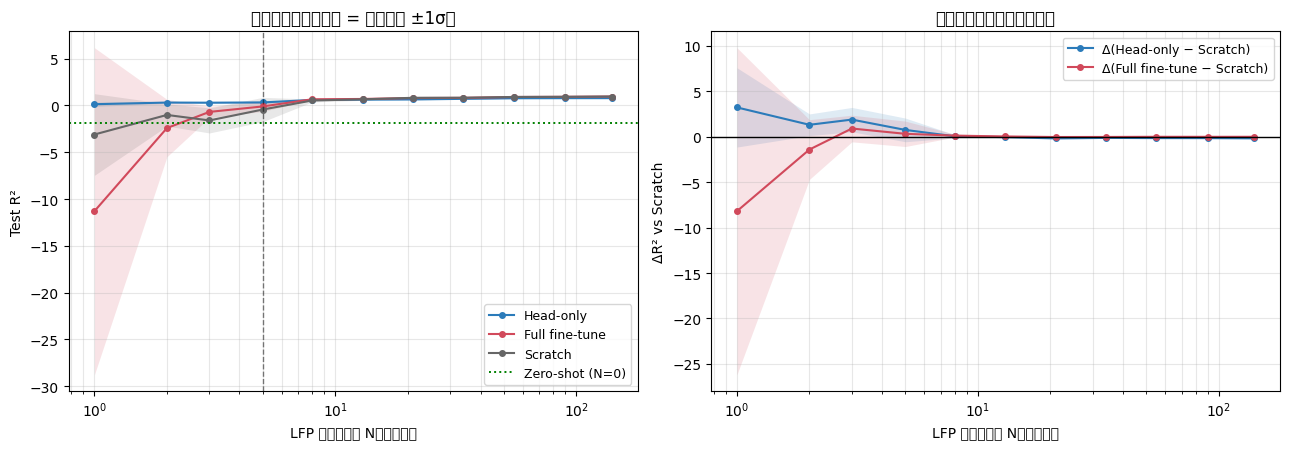


💾 已保存：label_efficiency_raw.csv / label_efficiency_agg.csv / label_efficiency.png


In [14]:
RUN_LABEL_EFFICIENCY = True       # 改成 True 再跑（约 300 次训练）

# ---- 训练电池数网格（对数间隔；超过训练池大小的档位会自动裁掉）----
N_CELLS_GRID = [1, 2, 3, 5, 8, 13, 21, 34, 55, 90, 140]

# ---- 每个 N 的重复抽样次数：N 越小方差越大，重复越多 ----
def n_repeats_for(n):
    if n <= 5:  return 5
    if n <= 34: return 3
    return 2

# ---- 验证集口径："fixed"=始终用满（乐观，推荐）/ "shrink"=同比例缩减（现实） ----
VAL_POLICY = "fixed"


if RUN_LABEL_EFFICIENCY:
    pool_arr = np.array(POOL_CELLS)
    va_arr   = np.array(VA_CELLS)
    N_POOL   = len(pool_arr)
    grid     = sorted({min(n, N_POOL) for n in N_CELLS_GRID})

    # 备份全局状态，跑完还原
    _bak = dict(X_tr=X_tr.copy(), y_tr=y_tr.copy(), X_va=X_va.copy(), y_va=y_va.copy(),
                tr_idx=tr_idx.copy(), TR_CELLS=list(TR_CELLS),
                xs=lfp_x_scaler, ys=lfp_y_scaler, bs=CUR_BS)

    print(f"训练池 {N_POOL} 块 | 验证 {len(va_arr)} 块 | 测试 {len(TE_CELLS)} 块")
    print(f"网格 N = {grid} | 验证集口径 = {VAL_POLICY}\n")

    curve_rows = []
    max_rep = max(n_repeats_for(n) for n in grid)

    # 纪律 ①：每个 repeat 只生成一次全排列，取前 N 个 → 子集天然嵌套
    perms    = [np.random.default_rng(SPLIT_SEED + 1000 * r).permutation(pool_arr)
                for r in range(max_rep)]
    va_perms = [np.random.default_rng(SPLIT_SEED + 7000 + 1000 * r).permutation(va_arr)
                for r in range(max_rep)]

    for n_cells in grid:
        for rep_i in range(n_repeats_for(n_cells)):          # 纪律 ②：重复抽样
            keep = set(perms[rep_i][:n_cells].tolist())
            sub_tr = np.isin(g_lfp[pool_idx], list(keep))
            X_tr, y_tr = X_lfp[pool_idx][sub_tr], y_lfp[pool_idx][sub_tr]

            # 纪律 ③：验证集口径
            if VAL_POLICY == "shrink":
                k_va = max(1, int(round(len(va_arr) * n_cells / N_POOL)))
                keep_va = set(va_perms[rep_i][:k_va].tolist())
                sub_va = np.isin(g_lfp[va_idx], list(keep_va))
                X_va, y_va = _bak["X_va"][sub_va], _bak["y_va"][sub_va]
            else:
                k_va = len(va_arr)
                X_va, y_va = _bak["X_va"], _bak["y_va"]

            # 纪律 ④：scaler 只在当前子集上 fit（否则用到预算外信息 = 泄露）
            lfp_x_scaler = StandardScaler().fit(X_tr)
            lfp_y_scaler = StandardScaler().fit(y_tr.reshape(-1, 1))
            SCALERS["lfp"] = lfp_x_scaler

            # 纪律 ⑤：batch size 自适应，保证 Scratch 有足够梯度更新步数
            CUR_BS = adaptive_bs(len(X_tr))
            steps = int(np.ceil(len(X_tr) / CUR_BS))

            print(f"[N={n_cells:3d} rep={rep_i}] 训练 {len(X_tr):6d} 行 / "
                  f"验证 {len(X_va):5d} 行 ({k_va} 块) | bs={CUR_BS} → {steps} 步/epoch")

            for name, init, oh, lr in [("Head-only",      NCA_STATES, True,  HEAD_LR),
                                       ("Full fine-tune", NCA_STATES, False, FULL_LR),
                                       ("Scratch",        None,       False, SCRATCH_LR)]:
                out = run_experiment(name, init_states=init, only_head=oh, lr=lr,
                                     verbose=False, store=False, quiet=True)
                curve_rows.append(dict(
                    n_cells=n_cells, rep=rep_i, n_rows=int(len(X_tr)),
                    n_val_cells=k_va, batch_size=CUR_BS, steps_per_epoch=steps,
                    method=name,
                    **{f"test_{a}": out["test"][a] for a in ["r2", "rmse", "mae"]}))

    # ---- 还原全局状态 ----
    X_tr, y_tr = _bak["X_tr"], _bak["y_tr"]
    X_va, y_va = _bak["X_va"], _bak["y_va"]
    tr_idx, TR_CELLS = _bak["tr_idx"], _bak["TR_CELLS"]
    lfp_x_scaler, lfp_y_scaler = _bak["xs"], _bak["ys"]
    SCALERS["lfp"] = lfp_x_scaler
    CUR_BS = _bak["bs"]

    curve = pd.DataFrame(curve_rows)
    curve.to_csv(RESULT_DIR / "label_efficiency_raw.csv", index=False)

    # ================== 聚合 ==================
    agg = (curve.groupby(["method", "n_cells"])
                .agg(r2_mean=("test_r2", "mean"), r2_std=("test_r2", "std"),
                     rmse_mean=("test_rmse", "mean"), rmse_std=("test_rmse", "std"),
                     n_rows=("n_rows", "mean"), reps=("test_r2", "size"))
                .reset_index().fillna(0.0))
    agg.to_csv(RESULT_DIR / "label_efficiency_agg.csv", index=False)
    print("\n" + agg.round(4).to_string(index=False))

    piv     = agg.pivot(index="n_cells", columns="method", values="r2_mean")
    std_piv = agg.pivot(index="n_cells", columns="method", values="r2_std")
    Ns = piv.index.values
    sc = piv["Scratch"].values

    # ================== 三个判据 ==================
    print("\n" + "=" * 74)
    print("判据 1 交叉点 N*  |  判据 2 等效标签量倍数 rho  |  判据 3 增益落入噪声带的 N")
    print("=" * 74)

    for m in ["Head-only", "Full fine-tune"]:
        tv = piv[m].values
        d  = tv - sc

        cross = None
        for i in range(len(Ns) - 1):
            if d[i] > 0 >= d[i + 1]:
                t = d[i] / (d[i] - d[i + 1])
                cross = Ns[i] + t * (Ns[i + 1] - Ns[i])
                break

        noise = np.sqrt(std_piv[m].values ** 2 + std_piv["Scratch"].values ** 2)
        below = [Ns[i] for i in range(len(Ns)) if d[i] <= noise[i]]

        print(f"\n【{m}】")
        print(f"  最大增益 ΔR² = {d.max():+.4f}  出现在 N = {Ns[int(np.argmax(d))]} 块")
        print(f"  交叉点 N*    = {f'{cross:.1f} 块' if cross else '未在网格内出现（迁移全程占优）'}")
        print(f"  增益进入噪声带的最小 N = {below[0] if below else '全程显著'}")
        print("  等效标签量：")
        for i, n in enumerate(Ns):
            if n > Ns[max(0, len(Ns) // 2)]:
                break
            hit = np.where(sc >= tv[i])[0]
            if len(hit) == 0:
                print(f"    N={n:3d} (R²={tv[i]:.4f}) → Scratch 用满 {Ns[-1]} 块仍未追上"
                      f"（rho > {Ns[-1]/n:.1f}x）")
            elif hit[0] == 0:
                print(f"    N={n:3d} (R²={tv[i]:.4f}) → Scratch 在最小规模就已追上（rho <= 1）")
            else:
                j = hit[0]
                x0, x1, y0, y1 = Ns[j - 1], Ns[j], sc[j - 1], sc[j]
                n_eq = x0 + (tv[i] - y0) / max(1e-12, y1 - y0) * (x1 - x0)
                print(f"    N={n:3d} (R²={tv[i]:.4f}) → Scratch 需 {n_eq:5.1f} 块，"
                      f"rho = {n_eq / n:4.1f}x")

    # ================== 作图：对数横轴 + 误差带 ==================
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    cmap = {"Head-only": "#2b7bba", "Full fine-tune": "#d1495b", "Scratch": "#666666"}

    ax = axes[0]
    for m in ["Head-only", "Full fine-tune", "Scratch"]:
        g = agg[agg.method == m].sort_values("n_cells")
        ax.plot(g.n_cells, g.r2_mean, marker="o", ms=4, color=cmap[m], label=m)
        ax.fill_between(g.n_cells, g.r2_mean - g.r2_std, g.r2_mean + g.r2_std,
                        color=cmap[m], alpha=0.15, lw=0)
    if "Zero-shot" in RESULTS:
        ax.axhline(RESULTS["Zero-shot"]["test"]["r2"], color="green", ls=":", lw=1.4,
                   label="Zero-shot (N=0)")
    ax.axvline(len(_bak["TR_CELLS"]), color="k", ls="--", lw=1, alpha=0.5)
    ax.set_xscale("log"); ax.set_xlabel("LFP 训练电池数 N（对数轴）")
    ax.set_ylabel("Test R²"); ax.set_title("标签效率曲线（阴影 = 重复抽样 ±1σ）")
    ax.legend(fontsize=9); ax.grid(alpha=0.3, which="both")

    ax = axes[1]
    for m in ["Head-only", "Full fine-tune"]:
        d  = piv[m].values - sc
        nz = np.sqrt(std_piv[m].values ** 2 + std_piv["Scratch"].values ** 2)
        ax.plot(Ns, d, marker="o", ms=4, color=cmap[m], label=f"Δ({m} − Scratch)")
        ax.fill_between(Ns, d - nz, d + nz, color=cmap[m], alpha=0.15, lw=0)
    ax.axhline(0, color="k", lw=1)
    ax.set_xscale("log"); ax.set_xlabel("LFP 训练电池数 N（对数轴）")
    ax.set_ylabel("ΔR² vs Scratch"); ax.set_title("迁移净增益随标签量的衰减")
    ax.legend(fontsize=9); ax.grid(alpha=0.3, which="both")

    plt.tight_layout()
    plt.savefig(RESULT_DIR / "label_efficiency.png", dpi=150)
    plt.show()
    print(f"\n💾 已保存：label_efficiency_raw.csv / label_efficiency_agg.csv / label_efficiency.png")
else:
    print("已跳过标签效率曲线（把 RUN_LABEL_EFFICIENCY 改成 True 即可运行）")


## 8. 结果怎么读

对照下表判断你落在哪一种情况：

| 观察到的现象 | 结论 |
|---|---|
| Zero-shot 差 → Head-only 明显变好 → Full FT 再提升 → 都优于 Scratch | NCA 不能直接泛化，但它的 32 维特征有用，LFP 需要同时调整特征与回归关系；**迁移成功** |
| Zero-shot 差，Head-only ≈ Scratch，Full FT > Scratch | NCA 的输出映射不适合 LFP，只训 head 不够，但 NCA 权重仍是个好初始化 |
| Head-only > Full fine-tune | NCA 底层特征迁移性好；LFP 数据量可能不足，全量微调参数太多导致过拟合 |
| Scratch > Head-only 且 Scratch > Full FT | 域差异过大，出现**负迁移**；当前 7 特征的物理表达跨化学体系还不够 |
| Zero-shot 已经很好 | 两种体系的松弛特征—SOH 关系本身相通；迁移主要作用只是校正偏置（对照 Zero-shot+cal 那一行） |

几个容易踩的坑：

- **只看 \(R^2\) 不够**。三个指标必须同向下降/上升，否则可能只是被少数离群电池带偏。
- **Zero-shot+cal 与 Zero-shot 的差距**是关键诊断量：差距大 → 问题主要在尺度/偏置；
  差距小但绝对值仍差 → 问题在特征—SOH 关系本身。
- **Full fine-tune 对 epoch 数和学习率很敏感**。若它的漂移表显示第一层变化极大，
  说明 LFP 实际上把网络重训了一遍，这时它与 Scratch 的差距会自然收窄。
- **R0 的可辨识性**。如果 R0 只由静置段拟合、而非电流切断瞬间辨识，它未必是独立可辨识参数，
  跨体系比较时要格外小心。同理，前段充放电倍率会改变静置起始的极化状态，
  即便 NCA 与 LFP 的 ECM 参数都来自各自真实的 15 分钟静置曲线、无需做 0.5C→3C 的比例换算，
  仍可能存在由倍率、化学体系、温度和拟合窗口造成的分布偏移——上面第 3 节的域偏移体检就是看这个。
- **主实验的 \(N\) 怎么定**：先跑第 7 节的曲线，把 `N_TRAIN_CELLS` 定在**最大增益点附近**
  （多数情况落在 3~8 块），完整曲线作为支撑材料。这样「为什么选这个数」就有实验依据，
  而不是拍脑袋。如果曲线显示 \(N^*\) 很小（比如 10 块以内 Scratch 就追平了），
  那么诚实的结论是「这个场景下迁移价值有限」——这同样是有价值的负结果。
- **别浪费训练池里没抽中的电池**。它们的输入特征 \(X\) 是免费的（拿 ECM 参数不需要完整老化标定），
  可以做无监督域适配（BN 统计量对齐 / CORAL）再叠加少量标签做 Head-only。
  这是唯一能同时利用大量无标签数据和少量标签的方案，通常比纯 Head-only 还好一截。
- **注意工况覆盖 vs 标签量的混淆**。若 LFP 电池覆盖多种工况/温度，\(N{=}3\) 时随机抽很可能
  三块全落在同一工况里。这时测到的不是「标签量不够」而是「工况覆盖不够」——
  两者的政策含义完全不同（前者说「多标几块」，后者说「标的时候要覆盖工况」）。
  有工况标签的话，建议把抽样改成按工况轮转，并额外记录一列「覆盖了几个工况」。
- 下一步若要加入**前序放电倍率**等特征，输入会从 7 维变成 8 维，
  `Linear(7,128)` 要改成 `Linear(8,128)`，此时 NCA 预训练权重的第一层无法直接复用，
  需要重新预训练 NCA，或只迁移第二层以后的部分。
